<div style="font-family: 'Arial', sans-serif; color: black; line-height: 1.6; margin-top: 40px; margin-bottom: 40px;">

<div style="font-size: 2.3em; font-weight: bold; color: #454545; margin-bottom: 5px; text-align: center;">The Anderson Darling Test</div>  
<div style="font-size: 1.7em; font-weight: lighter; color: #454545; margin-top: 5px; text-align: center;">Practical Implementation</div>  

<hr style="border: 1px solid #454545; width: 90%; margin: 20px auto;">

<span style="font-size: 2.3em; font-style: italic; color: #2C3E50;"> <div style="font-size: 1.3em; text-align: center;"> Reda Mdair </div></span> 
<BR><BR>
<!-- <div style="font-size: 1.1em; color: #2C3E50; margin-top: 20px; text-align: center;">2024</div>
 -->

    
    
## **_From Asymptotic Theory to Practical Implementation_**

<br>
    
This notebook provides a brief implementation of the Anderson–Darling goodness-of-fit test to give an intuitive understanding.
    
We will:  
- Derive the statistic from its integral form  
- Implement it via order statistics  
- Examine the weighting mechanism  
- Compare with Kolmogorov–Smirnov  

<br>

## Theoretical Background
    
<br>

Let $ X = (X_1, \dots, X_n) $ be an i.i.d. sample from an unknown distribution $P$.  
We test:

$$ (H_0): P = P^1 $$

Under $ H_0 $, defining

$$ u_i = F^1(X_i) $$

the transformed variables follow a Uniform(0,1) distribution.

The Anderson–Darling statistic can be expressed in its **original integral form**, highlighting the weight function $\psi(u)$:

$$
W_n^2(X) = n \int_{0}^{1} [G_n(u) - u]^2 \, \psi(u) \, du
$$

where:

- $G_n(u)$ is the **empirical CDF** of the transformed observations $u_i = F^1(X_i)$,  
- $u \in [0,1]$ because under $H_0$, the $u_i$ follow a Uniform(0,1) distribution,  
- $\psi(u)$ is a **positive weight function**. 

In the case of the classic Anderson–Darling test:

$$
\psi(u) = \frac{1}{u(1-u)}
$$

As a result, discrepancies in the tails contribute more heavily to the statistic.
    
Discrete formula at order statistics:
    
$$
W_n^2(X) = -n - \frac{1}{n}\sum_{i=1}^{n} (2i-1) \left[\log(u_i) + \log(1-u_{n-i+1})\right]
$$

The logarithms naturally encode the tail weighting, preserving the sensitivity of the integral representation in a computable form.
    
---

In [1]:
# ----- Libraries -----

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Implementation of the Anderson–Darling Statistic

<br>

We implement the statistic exactly as defined above.

Key implementation details:

- The sample must be sorted (order statistics).
- The theoretical CDF is evaluated at sorted points.
- Numerical stability is ensured to avoid $\log(0)$.
- The implementation is fully vectorized.

In [2]:
def anderson_darling_statistic(x, cdf):

    x = np.asarray(x)
    n = len(x)

    # Sort sample
    x_sorted = np.sort(x)

    # Evaluate theoretical CDF
    u = cdf(x_sorted)

    # Numerical stability: avoid log(0)
    eps = 1e-12
    u = np.clip(u, eps, 1 - eps)

    i = np.arange(1, n + 1)

    term = (2 * i - 1) * (np.log(u) + np.log(1 - u[::-1]))

    Wn2 = -n - np.mean(term)

    return Wn2

### Stephens Correction (Unknown Parameters Case)

<br>

When testing for normality, the mean and variance are typically unknown.

Michael Stephens proposed the corrected statistic:

$$
W^* = W_n^2
\left(
1 + \frac{0.75}{n} + \frac{2.25}{n^2}
\right)
$$

This improves the asymptotic approximation when parameters are estimated.

In [3]:
def anderson_darling_normal(x):
    
    """ Anderson-Darling test for normality using Stephens correction """
    x = np.asarray(x)
    n = len(x)

    mu = np.mean(x)
    sigma = np.std(x, ddof=1)

    cdf = lambda t: stats.norm.cdf(t, loc=mu, scale=sigma)

    Wn2 = anderson_darling_statistic(x, cdf)

    correction = 1 + 0.75/n + 2.25/(n**2)

    return Wn2 * correction

---

## 2. Weight Function - Tail Sensivity

<br>

The distinctive feature of the Anderson–Darling test lies in the weight function

$$
\psi(u) = \frac{1}{u(1-u)}
$$

which diverges near 0 and 1, giving strong emphasis to tail deviations. Central discrepancies contribute moderately.

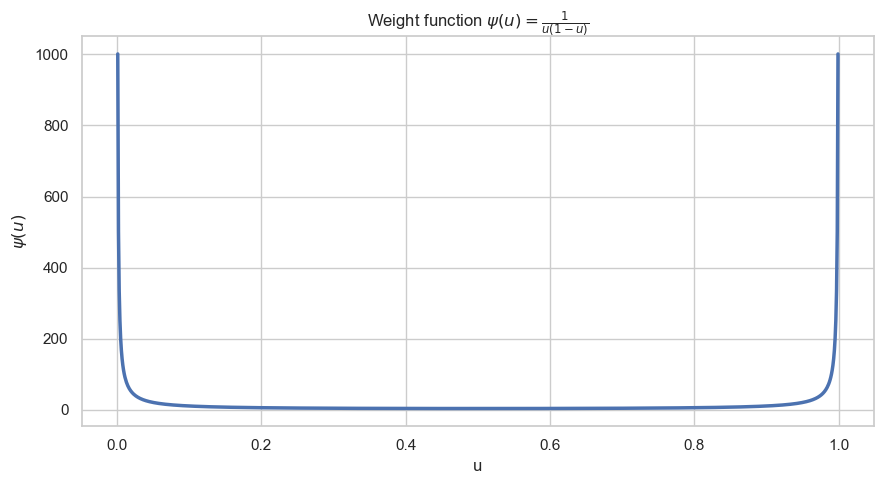

In [4]:
sns.set_theme(style="whitegrid", context="notebook")

u = np.linspace(0.001, 0.999, 1000)
psi = 1 / (u * (1 - u))

plt.figure(figsize=(9, 5))
plt.plot(u, psi, linewidth=2.5)

plt.title(r"Weight function $\psi(u) = \frac{1}{u(1-u)}$")
plt.xlabel("u")
plt.ylabel(r"$\psi(u)$")
plt.tight_layout()
plt.show()

The divergence of $\psi$ near 0 and 1 explains why Anderson–Darling is highly sensitive to tail deviations.

Implications:

- Small central deviations are moderately penalized.
- Extreme observations have disproportionate influence.
- This makes the test particularly relevant in risk modelling and anomaly detection.

---

## 3. Individual Contributions to the Statistic

<br>

Each observation contributes:

$$
(2i-1)\left[
\ln(u_i) + \ln(1 - u_{n-i+1})
\right]
$$

Extremes dominate; central values contribute symmetrically.

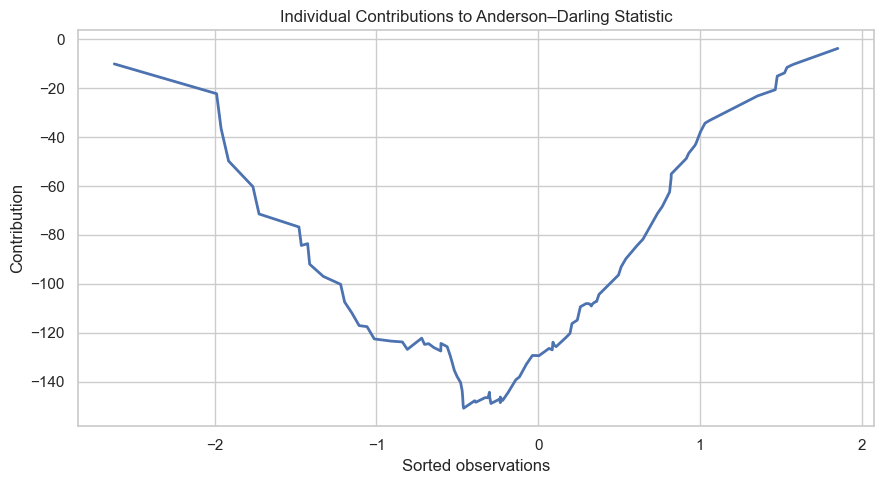

In [5]:
sns.set_theme(style="whitegrid", context="notebook")

def ad_contributions_normal(x):

    x = np.asarray(x)
    n = len(x)

    # Estimate parameters (Stephens setting) 
    mu = np.mean(x)
    sigma = np.std(x, ddof=1)

    # Order statistics 
    x_sorted = np.sort(x)

    # Probability integral transform 
    u = stats.norm.cdf(x_sorted, loc=mu, scale=sigma)

    # Numerical stability 
    eps = 1e-12
    u = np.clip(u, eps, 1 - eps)

    # Index vector 
    i = np.arange(1, n + 1)

    # Contribution formula 
    contributions = (2 * i - 1) * (
        np.log(u) + np.log(1 - u[::-1])
    )

    return x_sorted, contributions

# ==========================
# Example usage
# ==========================

np.random.seed(42)
x = np.random.normal(size=100)

x_sorted, contrib = ad_contributions_normal(x)

plt.figure(figsize=(9, 5))
plt.plot(x_sorted, contrib, linewidth=2)
plt.title("Individual Contributions to Anderson–Darling Statistic")
plt.xlabel("Sorted observations")
plt.ylabel("Contribution")
plt.tight_layout()
plt.show()

---

## 4. Simulation Study: Normal vs Exponential

<br>

We generate two samples:

- **Gaussian**, consistent with the null hypothesis  
- **Exponential**, representing a departure from normality

We compute **both Anderson–Darling and Kolmogorov–Smirnov statistics** for comparison.

> **Note** : Kolmogorov–Smirnov measures:
$$
\sup_x |F_n(x) - F(x)|
$$
It focuses on the maximum deviation, unlike Anderson–Darling which integrates squared deviations with tail weighting.

In [6]:
np.random.seed(42)
x_normal = np.random.normal(size=200)
x_exp = np.random.exponential(size=200)

# Anderson–Darling
print("AD (normal sample):", anderson_darling_normal(x_normal))
print("AD (exponential sample):", anderson_darling_normal(x_exp))

# Kolmogorov–Smirnov
ks_normal = stats.kstest(x_normal, 'norm', args=(np.mean(x_normal), np.std(x_normal, ddof=1)))
ks_exp = stats.kstest(x_exp, 'norm', args=(np.mean(x_exp), np.std(x_exp, ddof=1)))
print("KS (normal sample):", ks_normal.statistic)
print("KS (exponential sample):", ks_exp.statistic)

AD (normal sample): 0.2757489544094516
AD (exponential sample): 6.742313697660573
KS (normal sample): 0.038596399488743494
KS (exponential sample): 0.14555741046161286


**Observation:** The Anderson–Darling statistic separates the two cases more sharply than Kolmogorov–Smirnov, reflecting its structural emphasis on tail deviations where the Exponential distribution departs most from Gaussian symmetry.

---

## **_Synthesis_**

<br>

The Anderson–Darling test integrates squared discrepancies with increasing tail weight, in contrast to maximum-deviation approaches like Kolmogorov–Smirnov. Its structure makes it a principled, robust tool whenever extreme observations are substantively important.